<a href="https://colab.research.google.com/github/Nishikant090/Proactive-Handover-Trigger-Prediction-in-5G-Networks-Using-Time-Series-Forecasting-Models/blob/main/Final4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import LSTM, GRU, Dense
from tensorflow.keras.layers import Input, MultiHeadAttention, LayerNormalization, GlobalAveragePooling1D


In [2]:
from google.colab import files
uploaded = files.upload()


Saving drive_test_measurements01.csv to drive_test_measurements01.csv
Saving drive_test_measurements02.csv to drive_test_measurements02.csv
Saving drive_test_measurements03.csv to drive_test_measurements03.csv


In [3]:
df1 = pd.read_csv("drive_test_measurements01.csv")
df2 = pd.read_csv("drive_test_measurements02.csv")
df3 = pd.read_csv("drive_test_measurements03.csv")

df = pd.concat([df1, df2, df3], ignore_index=True)

# Use RSRP signal
data = df["RSRP"].values.reshape(-1,1)

print("Total samples:", data.shape)


Total samples: (8896, 1)


In [4]:
scaler = MinMaxScaler()
data_scaled = scaler.fit_transform(data)


In [5]:
SEQ_LEN = 10

X=[]
y=[]

for i in range(len(data_scaled)-SEQ_LEN):
    X.append(data_scaled[i:i+SEQ_LEN])
    y.append(data_scaled[i+SEQ_LEN])

X=np.array(X)
y=np.array(y)

print("X shape:",X.shape)


X shape: (8886, 10, 1)


In [6]:
gru_model = Sequential([
    GRU(64, input_shape=(X.shape[1], X.shape[2])),
    Dense(1)
])

gru_model.compile(optimizer="adam", loss="mse")
gru_model.fit(X,y,epochs=10,batch_size=32)

gru_pred = gru_model.predict(X)


Epoch 1/10


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


278/278 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - loss: 0.0217
Epoch 2/10
278/278 ━━━━━━━━━━━━━━━━━━━━ 5s 19ms/step - loss: 0.0029
Epoch 3/10
278/278 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.0026
Epoch 4/10
278/278 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.0026
Epoch 5/10
278/278 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.0026
Epoch 6/10
278/278 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0026
Epoch 7/10
278/278 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.0026
Epoch 8/10
278/278 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - loss: 0.0026
Epoch 9/10
278/278 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - loss: 0.0026
Epoch 10/10
278/278 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.0025
278/278 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


In [25]:
print(X.shape)


(8886, 10, 1)


In [7]:
inputs = Input(shape=(X.shape[1], X.shape[2]))

attn = MultiHeadAttention(num_heads=2, key_dim=2)(inputs, inputs)
norm = LayerNormalization()(attn + inputs)
pool = GlobalAveragePooling1D()(norm)
outputs = Dense(1)(pool)

trans_model = Model(inputs, outputs)
trans_model.compile(optimizer="adam", loss="mse")

trans_model.fit(X,y,epochs=10,batch_size=32)

trans_pred = trans_model.predict(X)


Epoch 1/10
278/278 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - loss: 0.1419
Epoch 2/10
278/278 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.0280
Epoch 3/10
278/278 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0247
Epoch 4/10
278/278 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0252
Epoch 5/10
278/278 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0247
Epoch 6/10
278/278 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0250
Epoch 7/10
278/278 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0248
Epoch 8/10
278/278 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0250
Epoch 9/10
278/278 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0240
Epoch 10/10
278/278 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0246
278/278 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


In [26]:
(8886, 10, 1)


(8886, 10, 1)

GRU + TRANSFORMER ACCURACY


In [8]:
threshold = np.mean(y)
labels = (y < threshold).astype(int).ravel()

features_GT = np.hstack([gru_pred, trans_pred])

X_train,X_test,y_train,y_test = train_test_split(
    features_GT,
    labels,
    test_size=0.2,
    random_state=42
)

rf_GT = RandomForestClassifier(n_estimators=200)
rf_GT.fit(X_train,y_train)

pred_GT = rf_GT.predict(X_test)

print("GRU + Transformer Accuracy:",
      accuracy_score(y_test,pred_GT))


GRU + Transformer Accuracy: 0.8543307086614174


ADD LSTM

In [9]:
lstm_model = Sequential([
    LSTM(64, input_shape=(X.shape[1], X.shape[2])),
    Dense(1)
])

lstm_model.compile(optimizer="adam", loss="mse")
lstm_model.fit(X,y,epochs=10,batch_size=32)

lstm_pred = lstm_model.predict(X)


Epoch 1/10


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


278/278 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - loss: 0.0135
Epoch 2/10
278/278 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.0034
Epoch 3/10
278/278 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.0033
Epoch 4/10
278/278 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - loss: 0.0029
Epoch 5/10
278/278 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.0027
Epoch 6/10
278/278 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.0027
Epoch 7/10
278/278 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.0026
Epoch 8/10
278/278 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.0026
Epoch 9/10
278/278 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.0026
Epoch 10/10
278/278 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.0026
278/278 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


In [10]:
features_ALL = np.hstack([
    lstm_pred,
    gru_pred,
    trans_pred
])

X_train,X_test,y_train,y_test = train_test_split(
    features_ALL,
    labels,
    test_size=0.2,
    random_state=42
)

rf_ALL = RandomForestClassifier(n_estimators=200)
rf_ALL.fit(X_train,y_train)

pred_ALL = rf_ALL.predict(X_test)

print("LSTM + GRU + Transformer Accuracy:",
      accuracy_score(y_test,pred_ALL))


LSTM + GRU + Transformer Accuracy: 0.8937007874015748


Add XGBoost

In [11]:
!pip install xgboost


In [14]:
from xgboost import XGBClassifier
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split

# Use telecom features
tab_features = df[
    ['RSRP','RSRQ','CINR','Distance (m)','Azimuth','Elevation']
].values

# Normalize
scaler_tab = MinMaxScaler()
tab_features = scaler_tab.fit_transform(tab_features)

# ⭐ IMPORTANT ALIGNMENT
tab_features = tab_features[SEQ_LEN:]

# Now lengths match labels
print(tab_features.shape, labels.shape)

Xt_train,Xt_test,yt_train,yt_test = train_test_split(
    tab_features,
    labels,
    test_size=0.2,
    random_state=42
)

xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05
)

xgb_model.fit(Xt_train,yt_train)


(8886, 6) (8886,)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.05, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=300,
              n_jobs=None, num_parallel_tree=None, ...)

In [29]:
print(tab_features.shape)


(8886, 6)


In [15]:
from sklearn.metrics import accuracy_score

xgb_pred_test = xgb_model.predict(Xt_test)

print("XGBoost Accuracy:",
      accuracy_score(yt_test,xgb_pred_test))


XGBoost Accuracy: 1.0


In [16]:
xgb_pred_all = xgb_model.predict(tab_features)
xgb_pred_all = xgb_pred_all.reshape(-1,1)


In [22]:
# Find smallest length
min_len = min(
    len(lstm_pred),
    len(gru_pred),
    len(trans_pred),
    len(xgb_pred_all)
)

print("Using aligned length:", min_len)

# Trim all predictions
lstm_aligned = lstm_pred[:min_len]
gru_aligned = gru_pred[:min_len]
trans_aligned = trans_pred[:min_len]
xgb_aligned = xgb_pred_all[:min_len]

# Stack features
features_four = np.hstack([
    lstm_aligned,
    gru_aligned,
    trans_aligned,
    xgb_aligned
])


Using aligned length: 8876


In [23]:
X_train,X_test,y_train,y_test = train_test_split(
    features_four,
    labels[:min_len],
    test_size=0.2,
    random_state=42
)

rf_final = RandomForestClassifier(n_estimators=300)
rf_final.fit(X_train,y_train)

pred_final = rf_final.predict(X_test)

print("FINAL 4-MODEL Accuracy:",
      accuracy_score(y_test,pred_final))


FINAL 4-MODEL Accuracy: 0.892454954954955


In [30]:
print(features_four.shape)


(8876, 4)


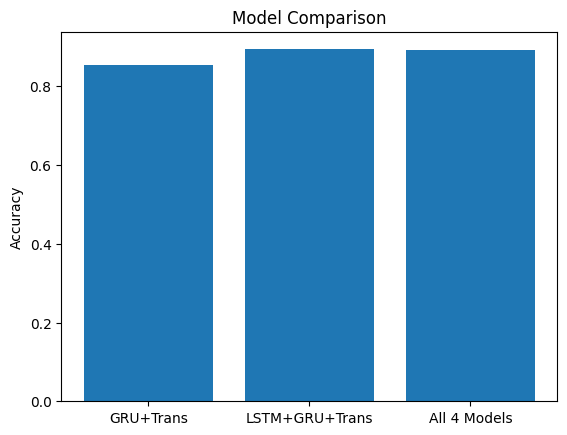

In [24]:
import matplotlib.pyplot as plt

models = [
    "GRU+Trans",
    "LSTM+GRU+Trans",
    "All 4 Models"
]

scores = [
    0.8543,
    0.8937,
    0.8925
]

plt.figure()
plt.bar(models, scores)
plt.ylabel("Accuracy")
plt.title("Model Comparison")
plt.show()
